First 5 rows:
         Date    Product  Sales  Quantity Region
0  2023-01-01  Product A    200         4  North
1  2023-01-02  Product B    150         3  South
2  2023-01-03  Product A    220         5  North
3  2023-01-04  Product C    300         6   East
4  2023-01-05  Product B    180         4   West

Missing values:
Date        0
Product     0
Sales       0
Quantity    0
Region      0
dtype: int64

Summary Statistics:
                      Date       Sales   Quantity
count                   16   16.000000  16.000000
mean   2023-01-08 12:00:00  237.500000   5.375000
min    2023-01-01 00:00:00  150.000000   3.000000
25%    2023-01-04 18:00:00  187.500000   4.000000
50%    2023-01-08 12:00:00  225.000000   5.500000
75%    2023-01-12 06:00:00  302.500000   7.000000
max    2023-01-16 00:00:00  340.000000   8.000000
std                    NaN   64.031242   1.746425

Product Summary:
     Product  Sales  Quantity
0  Product A   1350        33
1  Product B    850        17
2  Product C 

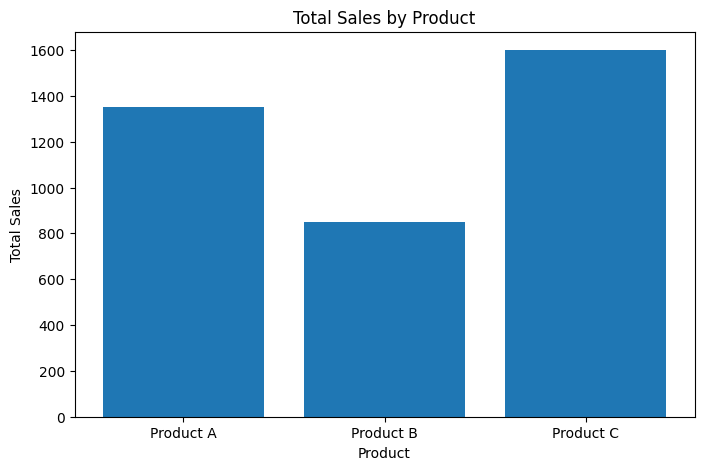

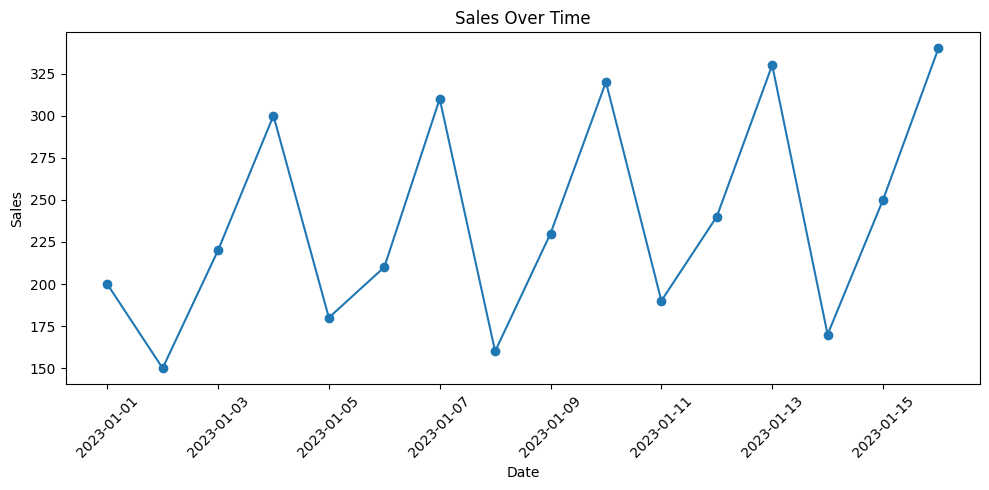


Sales by Region and Product:
Product  Product A  Product B  Product C
Region                                  
East             0          0       1600
North         1350          0          0
South            0        480          0
West             0        370          0

Correlation Matrix:
             Sales  Quantity
Sales     1.000000  0.944922
Quantity  0.944922  1.000000


/tmp/ipykernel_4019/489674682.py:61: FutureWarning: The provided callable <function sum at 0x7ab59bd94e00> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  pivot_table = df.pivot_table(


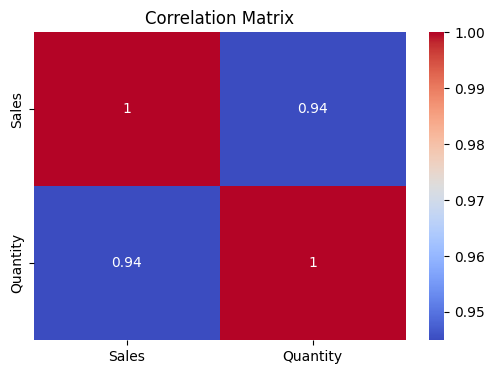

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load the dataset
df = pd.read_csv("/content/sales_data-2.csv")

# Display the first few rows
print("First 5 rows:")
print(df.head())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Fill missing Sales values, if any
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())

# Remove rows with missing Product, Quantity or Region
df.dropna(subset=['Product', 'Quantity', 'Region'], inplace=True)

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Group by Product and calculate total Sales and Quantity
product_summary = df.groupby('Product').agg({
    'Sales': 'sum',
        'Quantity': 'sum'
        }).reset_index()

print("\nProduct Summary:")
print(product_summary)


plt.figure(figsize=(8, 5))
plt.bar(product_summary['Product'], product_summary['Sales'])
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.title("Total Sales by Product")
plt.show()


sales_over_time = df.groupby('Date')['Sales'].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(sales_over_time['Date'], sales_over_time['Sales'], marker='o')
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pivot table - Sales by Region and Product
pivot_table = df.pivot_table(
values='Sales',
index='Region',
columns='Product',
aggfunc=np.sum,
fill_value=0
)

print("\nSales by Region and Product:")
print(pivot_table)


correlation_matrix = df[['Sales', 'Quantity']].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

# Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()